In [ ]:
################################################################################
#                 Arabic Book Age Classification - Full Pipeline
#                         Google Colab Notebook (v2 - Fixed)
################################################################################
# المشروع: تصنيف الكتب العربية حسب الفئة العمرية
# النهج: AraBert (50%) + Machine Learning (50%) = Weighted Ensemble
# الفئات: ٣-٨ | ٩-١٢ | ١٣-١٨ | ١٨-٢١ | ٢١+
################################################################################


In [ ]:
!pip install transformers torch pandas numpy scikit-learn xgboost openpyxl accelerate -q

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                    CELL 1: Installation & Setup                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
import os
import re
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from collections import Counter
import json
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import joblib
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA H100 80GB HBM3
GPU Memory: 85.0 GB


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                    CELL 2: Upload & Load Data                             ║
# ╚═══════════════════════════════════════════════════════════════════════════╝


df = pd.read_excel('/content/drive/MyDrive/zaid t/all_books_W_L.xlsx')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Total books: {df['Book Name'].nunique()}")
print(f"\nBooks per Age Category:")
print(df.groupby('Age Category')['Book Name'].nunique())
print(f"\nChunks per book (avg): {df.groupby('Book Name').size().mean():.0f}")


Dataset shape: (25680, 3)
Columns: ['Book Name', 'Content', 'Age Category']
Total books: 140

Books per Age Category:
Age Category
١٣-١٨    26
١٨-٢١    38
٢١+      38
٣-٨      13
٩-١٢     25
Name: Book Name, dtype: int64

Chunks per book (avg): 183


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                    CELL 3: Data Preprocessing                            ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF\s\.\,\;\:\!\?\-\(\)\"\']', ' ', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Clean_Content'] = df['Content'].apply(clean_arabic_text)

MIN_CHUNK_LENGTH = 50
df = df[df['Clean_Content'].str.len() >= MIN_CHUNK_LENGTH].reset_index(drop=True)
print(f"After filtering short chunks: {df.shape[0]} chunks remaining")

AGE_CATEGORY_MAP = {
    '٣-٨': 0,
    '٩-١٢': 1,
    '١٣-١٨': 2,
    '١٨-٢١': 3,
    '٢١+': 4
}
LABEL_TO_CATEGORY = {v: k for k, v in AGE_CATEGORY_MAP.items()}
NUM_LABELS = len(AGE_CATEGORY_MAP)

df['label'] = df['Age Category'].map(AGE_CATEGORY_MAP)
assert df['label'].isnull().sum() == 0, "Some categories were not mapped!"

print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index().rename(LABEL_TO_CATEGORY))

After filtering short chunks: 25673 chunks remaining

Label distribution:
label
٣-٨         23
٩-١٢      2050
١٣-١٨     2402
١٨-٢١     8749
٢١+      12449
Name: count, dtype: int64


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              CELL 4: Book-Level Train/Test Split                          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝


book_info = df.groupby('Book Name').agg(
    label=('label', 'first'),
    num_chunks=('label', 'count')
).reset_index()

train_books, test_books = train_test_split(
    book_info['Book Name'],
    test_size=0.2,
    random_state=42,
    stratify=book_info['label']
)

df_train = df[df['Book Name'].isin(train_books)].reset_index(drop=True)
df_test = df[df['Book Name'].isin(test_books)].reset_index(drop=True)

print(f"Train: {len(train_books)} books, {len(df_train)} chunks")
print(f"Test:  {len(test_books)} books, {len(df_test)} chunks")
print(f"\nTrain label distribution:")
print(df_train.groupby('label')['Book Name'].nunique().rename(LABEL_TO_CATEGORY))
print(f"\nTest label distribution:")
print(df_test.groupby('label')['Book Name'].nunique().rename(LABEL_TO_CATEGORY))

Train: 112 books, 20349 chunks
Test:  28 books, 5324 chunks

Train label distribution:
label
٣-٨      11
٩-١٢     20
١٣-١٨    21
١٨-٢١    30
٢١+      30
Name: Book Name, dtype: int64

Test label distribution:
label
٣-٨      2
٩-١٢     5
١٣-١٨    5
١٨-٢١    8
٢١+      8
Name: Book Name, dtype: int64


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              CELL 5: AraBert - Dataset & Tokenizer Setup                  ║
# ╚═══════════════════════════════════════════════════════════════════════════╝


MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Fix padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    if tokenizer.pad_token is None:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})

print(f"Model: {MODEL_NAME}")
print(f"Pad token: {tokenizer.pad_token}")


class ArabicChunkDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


train_dataset = ArabicChunkDataset(
    df_train['Clean_Content'].tolist(),
    df_train['label'].tolist(),
    tokenizer,
    MAX_LENGTH
)

test_dataset = ArabicChunkDataset(
    df_test['Clean_Content'].tolist(),
    df_test['label'].tolist(),
    tokenizer,
    MAX_LENGTH
)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

# Quick sanity check
sample = train_dataset[0]
print(f"Sample input_ids shape: {sample['input_ids'].shape}")
print(f"Sample attention_mask shape: {sample['attention_mask'].shape}")
print(f"Sample label: {sample['labels']}")

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model: aubmindlab/bert-base-arabertv02
Pad token: [PAD]
Train dataset: 20349 samples
Test dataset:  5324 samples
Sample input_ids shape: torch.Size([512])
Sample attention_mask shape: torch.Size([512])
Sample label: 2


In [ ]:


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              CELL 6: AraBert - Fine-Tuning                                ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification",
    ignore_mismatched_sizes=True
)

# Fix pad token in model config
model.config.pad_token_id = tokenizer.pad_token_id

# Resize embeddings if we added new tokens
model.resize_token_embeddings(len(tokenizer))

model.to(device)

# Class weights for imbalanced data
class_counts = df_train['label'].value_counts().sort_index().values.astype(float)
class_weights = torch.tensor(
    [len(df_train) / (NUM_LABELS * c) for c in class_counts],
    dtype=torch.float32
).to(device)
print(f"Class weights: {class_weights.cpu().numpy()}")


class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted'),
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted')
    }


training_args = TrainingArguments(
    output_dir='./arabert_results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    report_to='none',
    seed=42
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting AraBert fine-tuning...")
print("=" * 60)
train_result = trainer.train()
print("=" * 60)
print("Training complete!")
print(f"Training loss: {train_result.training_loss:.4f}")

eval_results = trainer.evaluate()
print(f"\nEvaluation Results:")
for key, value in eval_results.items():
    if 'eval_' in key:
        print(f"  {key}: {value:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Class weights: [214.2          2.4024794    2.113084     0.67069876   0.3824281 ]
Starting AraBert fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.372067,1.574040,0.724267,0.727829,0.733897,0.724267
2,0.152339,2.114193,0.674117,0.690822,0.731531,0.674117
3,0.075006,1.806292,0.783246,0.770114,0.765650,0.783246
4,0.081434,1.984558,0.754696,0.759608,0.769984,0.754696
5,0.000131,2.139390,0.747558,0.748451,0.757779,0.747558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete!
Training loss: 0.1688



Evaluation Results:
  eval_loss: 1.8065
  eval_accuracy: 0.7827
  eval_f1: 0.7697
  eval_precision: 0.7651
  eval_recall: 0.7827
  eval_runtime: 3.2951
  eval_samples_per_second: 1615.7430
  eval_steps_per_second: 50.6820


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              CELL 7: AraBert - Chunk-Level Predictions                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

predictions_output = trainer.predict(test_dataset)
chunk_logits = predictions_output.predictions
chunk_probs = torch.softmax(torch.tensor(chunk_logits), dim=-1).numpy()
chunk_preds = np.argmax(chunk_logits, axis=-1)

df_test = df_test.copy()
df_test['chunk_pred'] = chunk_preds
df_test['chunk_confidence'] = chunk_probs.max(axis=1)

for i in range(NUM_LABELS):
    df_test[f'prob_class_{i}'] = chunk_probs[:, i]

print(f"Chunk-level accuracy: {accuracy_score(df_test['label'], df_test['chunk_pred']):.4f}")

Chunk-level accuracy: 0.7827


In [ ]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║          CELL 8: AraBert - Book-Level Aggregation (Majority Vote)        ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def aggregate_llm_predictions(df_book_chunks):
    results = {}
    for book_name, group in df_book_chunks.groupby('Book Name'):
        true_label = int(group['label'].iloc[0])
        chunk_predictions = group['chunk_pred'].values
        total_chunks = len(chunk_predictions)

        vote_counts = Counter(chunk_predictions)
        majority_label = int(vote_counts.most_common(1)[0][0])
        majority_count = vote_counts.most_common(1)[0][1]
        confidence = majority_count / total_chunks

        prob_cols = [f'prob_class_{i}' for i in range(NUM_LABELS)]
        avg_probs = group[prob_cols].mean().values.astype(float)

        results[book_name] = {
            'true_label': true_label,
            'llm_predicted_label': majority_label,
            'llm_confidence': float(confidence),
            'llm_avg_probs': avg_probs,
            'total_chunks': total_chunks,
            'vote_distribution': {int(k): int(v) for k, v in vote_counts.items()}
        }

    return pd.DataFrame(results).T


llm_book_results = aggregate_llm_predictions(df_test)
llm_book_results.index.name = 'Book Name'
llm_book_results = llm_book_results.reset_index()

# Ensure correct types
llm_book_results['true_label'] = llm_book_results['true_label'].astype(int)
llm_book_results['llm_predicted_label'] = llm_book_results['llm_predicted_label'].astype(int)
llm_book_results['llm_confidence'] = llm_book_results['llm_confidence'].astype(float)

print("LLM Book-Level Results:")
print(f"  Accuracy: {accuracy_score(llm_book_results['true_label'], llm_book_results['llm_predicted_label']):.4f}")
print(f"  Avg Confidence: {llm_book_results['llm_confidence'].mean():.4f}")
print(f"\n{llm_book_results[['Book Name', 'true_label', 'llm_predicted_label', 'llm_confidence']].to_string()}")


LLM Book-Level Results:
  Accuracy: 0.7143
  Avg Confidence: 0.9007

                                              Book Name  true_label  llm_predicted_label  llm_confidence
0                                            أبو الحسن1           1                    1        0.815789
1                                            أرض السواد           3                    3        0.834635
2                                          أسطورة سيزيف           4                    4        0.897727
3                                    الأخوة كارامازوف 2           3                    3        0.984772
4                                          الأدب_الكبير           3                    2        0.809524
5                                     الإمتاع والمؤانسة           4                    3        0.596288
6                                 الاشجار واغتيال مرزوق           3                    3        0.988950
7   البحث عن الزمن المفقود الجزء 2 في ظلال ربيع الفتيات           4                    4   

In [ ]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║          CELL 9: Feature Engineering for ML Model                         ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def extract_book_features(df_chunks):
    features_list = []

    for book_name, group in df_chunks.groupby('Book Name'):
        texts = group['Clean_Content'].tolist()
        full_text = ' '.join(texts)
        label = int(group['label'].iloc[0])

        words = full_text.split()
        total_words = len(words)
        total_chars = len(full_text)
        num_chunks = len(texts)

        # Word-level features
        word_lengths = [len(w) for w in words] if words else [0]
        avg_word_length = np.mean(word_lengths)
        std_word_length = np.std(word_lengths)
        max_word_length = max(word_lengths)
        min_word_length = min(word_lengths)
        median_word_length = np.median(word_lengths)

        # Sentence-level features
        sentences = re.split(r'[.!?؟،\n]+', full_text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
        num_sentences = max(len(sentences), 1)

        sentence_lengths = [len(s.split()) for s in sentences] if sentences else [0]
        avg_sentence_length = np.mean(sentence_lengths)
        std_sentence_length = np.std(sentence_lengths)
        max_sentence_length = max(sentence_lengths)

        # Vocabulary richness
        unique_words = set(words)
        vocab_size = len(unique_words)
        type_token_ratio = vocab_size / total_words if total_words > 0 else 0

        word_freq = Counter(words)
        hapax_count = sum(1 for w, c in word_freq.items() if c == 1)
        hapax_ratio = hapax_count / total_words if total_words > 0 else 0

        # Complexity indicators
        long_words = [w for w in words if len(w) > 6]
        long_word_ratio = len(long_words) / total_words if total_words > 0 else 0

        short_words = [w for w in words if len(w) < 3]
        short_word_ratio = len(short_words) / total_words if total_words > 0 else 0

        medium_words = [w for w in words if 3 <= len(w) <= 6]
        medium_word_ratio = len(medium_words) / total_words if total_words > 0 else 0

        # Punctuation features
        num_periods = full_text.count('.')
        num_commas = full_text.count('،') + full_text.count(',')
        num_question_marks = full_text.count('؟') + full_text.count('?')
        num_exclamation = full_text.count('!')
        num_quotes = full_text.count('"') + full_text.count('"') + full_text.count('"')
        num_parentheses = full_text.count('(') + full_text.count(')')

        punctuation_density = (
            num_periods + num_commas + num_question_marks + num_exclamation
        ) / total_words if total_words > 0 else 0

        # Dialogue indicators
        dialogue_markers = full_text.count(':') + full_text.count('"') + full_text.count('«') + full_text.count('»')
        dialogue_ratio = dialogue_markers / num_sentences if num_sentences > 0 else 0

        # Chunk-level statistics
        chunk_lengths = [len(t.split()) for t in texts]
        avg_chunk_words = np.mean(chunk_lengths)
        std_chunk_words = np.std(chunk_lengths)

        # Readability proxies
        avg_syllables_per_word = avg_word_length / 2.5
        reading_ease_proxy = 206.835 - (1.015 * avg_sentence_length) - (84.6 * avg_syllables_per_word)

        # Word frequency distribution
        if word_freq:
            freq_values = list(word_freq.values())
            freq_mean = np.mean(freq_values)
            freq_std = np.std(freq_values)
            freq_max = max(freq_values)
            freq_skewness = (3 * (freq_mean - np.median(freq_values))) / freq_std if freq_std > 0 else 0
        else:
            freq_mean = freq_std = freq_max = freq_skewness = 0

        # Character-level features
        arabic_letter_count = len(re.findall(r'[\u0600-\u06FF]', full_text))
        digit_count = len(re.findall(r'\d', full_text))
        space_ratio = full_text.count(' ') / total_chars if total_chars > 0 else 0

        # Repetition features
        bigrams = [' '.join(words[i:i+2]) for i in range(len(words)-1)]
        unique_bigrams = len(set(bigrams))
        bigram_ratio = unique_bigrams / len(bigrams) if bigrams else 0

        features_list.append({
            'Book Name': book_name,
            'label': label,
            'total_words': total_words,
            'total_chars': total_chars,
            'num_chunks': num_chunks,
            'num_sentences': num_sentences,
            'avg_word_length': avg_word_length,
            'std_word_length': std_word_length,
            'max_word_length': max_word_length,
            'min_word_length': min_word_length,
            'median_word_length': median_word_length,
            'avg_sentence_length': avg_sentence_length,
            'std_sentence_length': std_sentence_length,
            'max_sentence_length': max_sentence_length,
            'words_per_sentence': total_words / num_sentences,
            'vocab_size': vocab_size,
            'type_token_ratio': type_token_ratio,
            'hapax_ratio': hapax_ratio,
            'long_word_ratio': long_word_ratio,
            'short_word_ratio': short_word_ratio,
            'medium_word_ratio': medium_word_ratio,
            'punctuation_density': punctuation_density,
            'question_mark_ratio': num_question_marks / num_sentences,
            'exclamation_ratio': num_exclamation / num_sentences,
            'dialogue_ratio': dialogue_ratio,
            'avg_chunk_words': avg_chunk_words,
            'std_chunk_words': std_chunk_words,
            'reading_ease_proxy': reading_ease_proxy,
            'freq_mean': freq_mean,
            'freq_std': freq_std,
            'freq_max': freq_max,
            'freq_skewness': freq_skewness,
            'space_ratio': space_ratio,
            'bigram_ratio': bigram_ratio,
        })

    return pd.DataFrame(features_list)


print("Extracting features for training books...")
train_features = extract_book_features(df_train)
print("Extracting features for test books...")
test_features = extract_book_features(df_test)

print(f"\nTrain features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")

feature_cols = [c for c in train_features.columns if c not in ['Book Name', 'label']]
print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Extracting features for training books...
Extracting features for test books...

Train features shape: (112, 34)
Test features shape: (28, 34)

Feature columns (32):
   1. total_words
   2. total_chars
   3. num_chunks
   4. num_sentences
   5. avg_word_length
   6. std_word_length
   7. max_word_length
   8. min_word_length
   9. median_word_length
  10. avg_sentence_length
  11. std_sentence_length
  12. max_sentence_length
  13. words_per_sentence
  14. vocab_size
  15. type_token_ratio
  16. hapax_ratio
  17. long_word_ratio
  18. short_word_ratio
  19. medium_word_ratio
  20. punctuation_density
  21. question_mark_ratio
  22. exclamation_ratio
  23. dialogue_ratio
  24. avg_chunk_words
  25. std_chunk_words
  26. reading_ease_proxy
  27. freq_mean
  28. freq_std
  29. freq_max
  30. freq_skewness
  31. space_ratio
  32. bigram_ratio


In [ ]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║          CELL 10: ML Model Training (XGBoost + Random Forest)            ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

X_train_ml = train_features[feature_cols].values.astype(float)
y_train_ml = train_features['label'].values.astype(int)
X_test_ml = test_features[feature_cols].values.astype(float)
y_test_ml = test_features['label'].values.astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ml)
X_test_scaled = scaler.transform(X_test_ml)

# Handle NaN/Inf
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=3,
    random_state=42
)

print("=" * 50)
models = {'XGBoost': xgb_model, 'Random Forest': rf_model, 'Gradient Boosting': gb_model}


for name, mdl in models.items():
    mdl.fit(X_train_scaled, y_train_ml)

print("\n\nTest Set Results:")
print("=" * 50)
ml_predictions = {}
ml_probabilities = {}

for name, mdl in models.items():
    preds = mdl.predict(X_test_scaled)
    probs = mdl.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test_ml, preds)
    f1 = f1_score(y_test_ml, preds, average='weighted')
    ml_predictions[name] = preds
    ml_probabilities[name] = probs
    print(f"{name:20s} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

# Ensemble ML (average probabilities)
avg_ml_probs = np.mean([ml_probabilities[name] for name in models], axis=0)
ml_ensemble_preds = np.argmax(avg_ml_probs, axis=1)
ml_ensemble_confidence = avg_ml_probs.max(axis=1)

print(f"\n{'ML Ensemble':20s} | Accuracy: {accuracy_score(y_test_ml, ml_ensemble_preds):.4f} | F1: {f1_score(y_test_ml, ml_ensemble_preds, average='weighted'):.4f}")

# Feature importance
print("\n\nTop 15 Most Important Features (XGBoost):")
print("=" * 50)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in importance_df.head(15).iterrows():
    print(f"  {row['feature']:25s} | {row['importance']:.4f}")



Test Set Results:
XGBoost              | Accuracy: 0.7143 | F1: 0.7258
Random Forest        | Accuracy: 0.6786 | F1: 0.6830
Gradient Boosting    | Accuracy: 0.6429 | F1: 0.6538

ML Ensemble          | Accuracy: 0.6429 | F1: 0.6538


Top 15 Most Important Features (XGBoost):
  total_words               | 0.1135
  num_chunks                | 0.1006
  freq_std                  | 0.0622
  freq_skewness             | 0.0596
  type_token_ratio          | 0.0577
  total_chars               | 0.0431
  freq_max                  | 0.0394
  max_sentence_length       | 0.0361
  vocab_size                | 0.0358
  hapax_ratio               | 0.0289
  punctuation_density       | 0.0289
  std_sentence_length       | 0.0281
  long_word_ratio           | 0.0270
  num_sentences             | 0.0250
  std_chunk_words           | 0.0246


In [ ]:


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║    CELL 11: Final Weighted Ensemble (70% LLM + 30% ML)                  ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

W_LLM = 0.50
W_ML = 0.50

def weighted_ensemble_prediction(llm_results_df, test_features_df, ml_probs_array,
                                 ml_preds_array, ml_conf_array, w_llm=0.50, w_ml=0.50):
    results = []

    for i in range(len(llm_results_df)):
        llm_row = llm_results_df.iloc[i]
        book_name = llm_row['Book Name']
        true_label = int(llm_row['true_label'])

        llm_probs = np.array(llm_row['llm_avg_probs'], dtype=float)
        ml_probs = ml_probs_array[i].astype(float)

        final_probs = (w_llm * llm_probs) + (w_ml * ml_probs)
        final_prediction = int(np.argmax(final_probs))
        final_confidence = float(final_probs[final_prediction])

        results.append({
            'Book Name': book_name,
            'true_label': true_label,
            'true_category': LABEL_TO_CATEGORY[true_label],
            'llm_prediction': int(llm_row['llm_predicted_label']),
            'llm_confidence': float(llm_row['llm_confidence']),
            'ml_prediction': int(ml_preds_array[i]),
            'ml_confidence': float(ml_conf_array[i]),
            'final_prediction': final_prediction,
            'final_confidence': final_confidence,
            'final_category': LABEL_TO_CATEGORY[final_prediction],
        })

    return pd.DataFrame(results)


# Sort both results by Book Name to align
llm_sorted = llm_book_results.sort_values('Book Name').reset_index(drop=True)
test_feat_sorted = test_features.sort_values('Book Name').reset_index(drop=True)

assert list(llm_sorted['Book Name']) == list(test_feat_sorted['Book Name']), \
    "Book order mismatch between LLM and ML results!"

# Recompute ML probs in sorted order
sorted_book_names = test_feat_sorted['Book Name'].tolist()
original_book_names = test_features['Book Name'].tolist()
sort_map = [original_book_names.index(bn) for bn in sorted_book_names]

avg_ml_probs_sorted = avg_ml_probs[sort_map]
ml_ensemble_preds_sorted = ml_ensemble_preds[sort_map]
ml_ensemble_conf_sorted = ml_ensemble_confidence[sort_map]

final_results = weighted_ensemble_prediction(
    llm_sorted, test_feat_sorted,
    avg_ml_probs_sorted, ml_ensemble_preds_sorted, ml_ensemble_conf_sorted,
    w_llm=W_LLM, w_ml=W_ML
)

print("=" * 80)
print(f"    FINAL ENSEMBLE RESULTS (LLM={W_LLM*100:.0f}% + ML={W_ML*100:.0f}%)")
print("=" * 80)

    FINAL ENSEMBLE RESULTS (LLM=50% + ML=50%)


In [ ]:


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                  CELL 12: Comprehensive Evaluation                       ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

y_true = final_results['true_label'].values.astype(int)
y_pred_llm = final_results['llm_prediction'].values.astype(int)
y_pred_ml = final_results['ml_prediction'].values.astype(int)
y_pred_final = final_results['final_prediction'].values.astype(int)

target_names = [LABEL_TO_CATEGORY[i] for i in range(NUM_LABELS)]

print("\n📊 ACCURACY COMPARISON:")
print(f"  AraBert (LLM) only:     {accuracy_score(y_true, y_pred_llm):.4f}")
print(f"  ML Ensemble only:       {accuracy_score(y_true, y_pred_ml):.4f}")
print(f"  Weighted Ensemble:      {accuracy_score(y_true, y_pred_final):.4f}")

print(f"\n📊 F1-SCORE COMPARISON (Weighted):")
print(f"  AraBert (LLM) only:     {f1_score(y_true, y_pred_llm, average='weighted'):.4f}")
print(f"  ML Ensemble only:       {f1_score(y_true, y_pred_ml, average='weighted'):.4f}")
print(f"  Weighted Ensemble:      {f1_score(y_true, y_pred_final, average='weighted'):.4f}")

print("\n\n📋 CLASSIFICATION REPORT (Final Ensemble):")
print(classification_report(y_true, y_pred_final, target_names=target_names))

print("\n📖 PER-BOOK PREDICTIONS:")
print("=" * 100)
for _, row in final_results.iterrows():
    match = "✅" if row['true_label'] == row['final_prediction'] else "❌"
    print(f"  {match} {str(row['Book Name'])[:40]:42s} | True: {row['true_category']:6s} | "
          f"Pred: {row['final_category']:6s} | "
          f"LLM: {row['llm_confidence']:.2f} | ML: {row['ml_confidence']:.2f} | "
          f"Final: {row['final_confidence']:.2f}")


📊 ACCURACY COMPARISON:
  AraBert (LLM) only:     0.7143
  ML Ensemble only:       0.6429
  Weighted Ensemble:      0.8214

📊 F1-SCORE COMPARISON (Weighted):
  AraBert (LLM) only:     0.6821
  ML Ensemble only:       0.6538
  Weighted Ensemble:      0.8106


📋 CLASSIFICATION REPORT (Final Ensemble):
              precision    recall  f1-score   support

         ٣-٨       1.00      1.00      1.00         2
        ٩-١٢       1.00      0.80      0.89         5
       ١٣-١٨       0.67      0.40      0.50         5
       ١٨-٢١       0.70      0.88      0.78         8
         ٢١+       0.89      1.00      0.94         8

    accuracy                           0.82        28
   macro avg       0.85      0.82      0.82        28
weighted avg       0.82      0.82      0.81        28


📖 PER-BOOK PREDICTIONS:
  ✅ أبو الحسن1                                 | True: ٩-١٢   | Pred: ٩-١٢   | LLM: 0.82 | ML: 0.58 | Final: 0.50
  ✅ أرض السواد                                 | True: ١٨-٢١  | Pred: ١

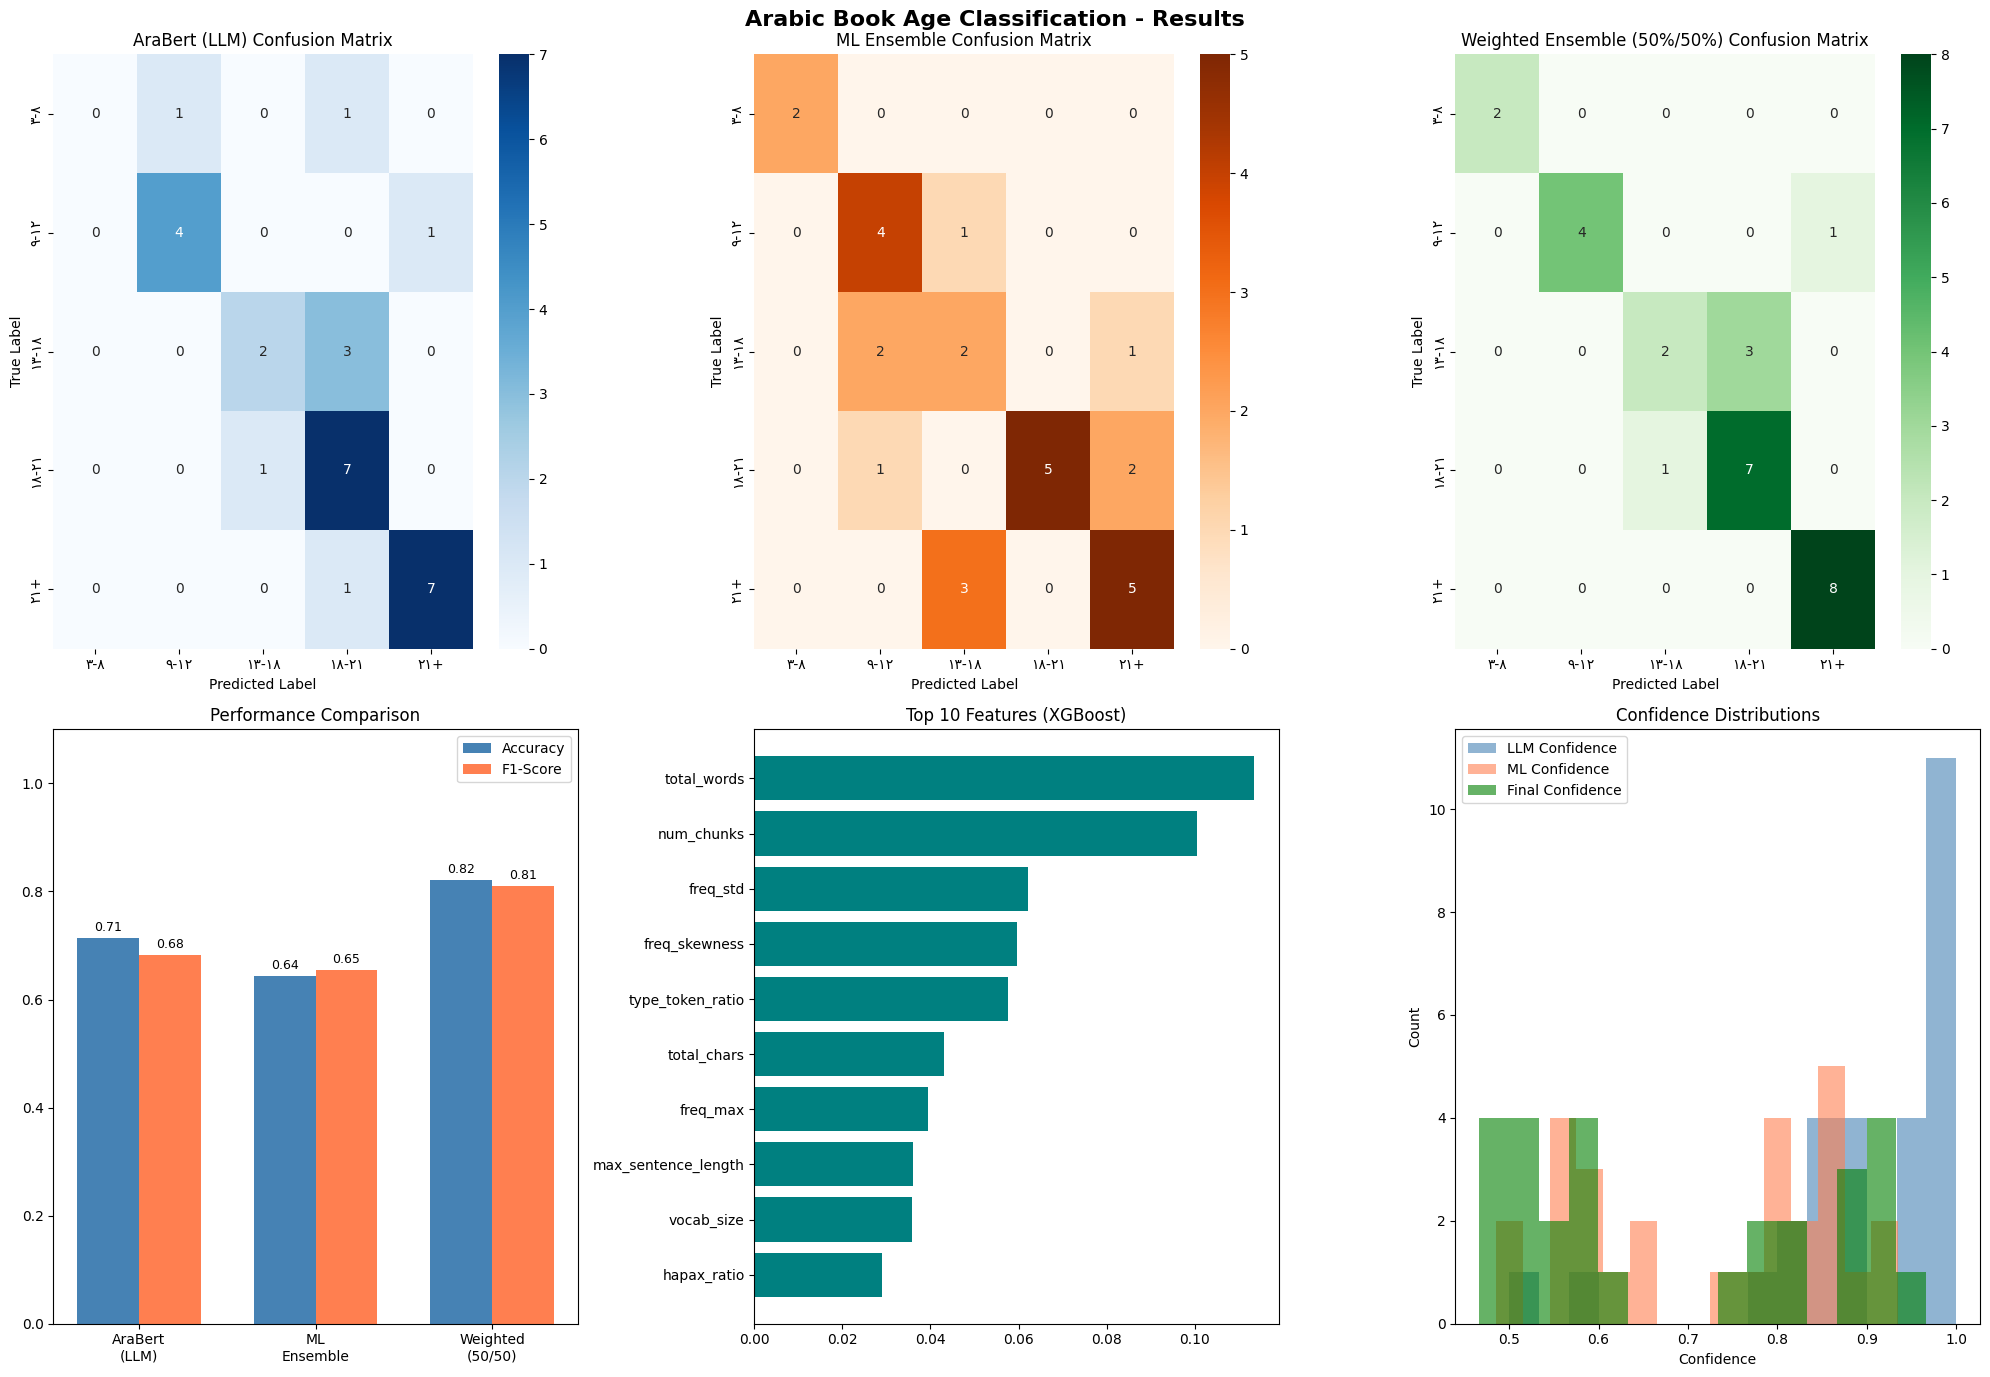

Visualization saved!


In [ ]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                  CELL 13: Visualization                                  ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Arabic Book Age Classification - Results', fontsize=16, fontweight='bold')

# Confusion Matrix - LLM
cm_llm = confusion_matrix(y_true, y_pred_llm)
sns.heatmap(cm_llm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 0].set_title('AraBert (LLM) Confusion Matrix')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Confusion Matrix - ML
cm_ml = confusion_matrix(y_true, y_pred_ml)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 1].set_title('ML Ensemble Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Confusion Matrix - Final
cm_final = confusion_matrix(y_true, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', ax=axes[0, 2],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 2].set_title(f'Weighted Ensemble ({W_LLM*100:.0f}%/{W_ML*100:.0f}%) Confusion Matrix')
axes[0, 2].set_ylabel('True Label')
axes[0, 2].set_xlabel('Predicted Label')

# Accuracy Comparison
methods = ['AraBert\n(LLM)', 'ML\nEnsemble', f'Weighted\n({W_LLM*100:.0f}/{W_ML*100:.0f})']
accuracies = [
    accuracy_score(y_true, y_pred_llm),
    accuracy_score(y_true, y_pred_ml),
    accuracy_score(y_true, y_pred_final)
]
f1_scores_list = [
    f1_score(y_true, y_pred_llm, average='weighted'),
    f1_score(y_true, y_pred_ml, average='weighted'),
    f1_score(y_true, y_pred_final, average='weighted')
]

x_pos = np.arange(len(methods))
width = 0.35
bars1 = axes[1, 0].bar(x_pos - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = axes[1, 0].bar(x_pos + width/2, f1_scores_list, width, label='F1-Score', color='coral')
axes[1, 0].set_ylim(0, 1.1)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(methods)
axes[1, 0].set_title('Performance Comparison')
axes[1, 0].legend()
for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    axes[1, 0].annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# Feature Importance
top_features = importance_df.head(10)
axes[1, 1].barh(range(len(top_features)), top_features['importance'].values, color='teal')
axes[1, 1].set_yticks(range(len(top_features)))
axes[1, 1].set_yticklabels(top_features['feature'].values)
axes[1, 1].set_title('Top 10 Features (XGBoost)')
axes[1, 1].invert_yaxis()

# Confidence Distribution
axes[1, 2].hist(final_results['llm_confidence'], bins=15, alpha=0.6, label='LLM Confidence', color='steelblue')
axes[1, 2].hist(final_results['ml_confidence'], bins=15, alpha=0.6, label='ML Confidence', color='coral')
axes[1, 2].hist(final_results['final_confidence'], bins=15, alpha=0.6, label='Final Confidence', color='green')
axes[1, 2].set_title('Confidence Distributions')
axes[1, 2].set_xlabel('Confidence')
axes[1, 2].set_ylabel('Count')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

In [ ]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              CELL 14: Weight Optimization                                ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

print("Weight Optimization - Testing different LLM/ML weight ratios:")
print("=" * 60)

best_f1 = 0
best_weights = (0.5, 0.5)
best_acc = 0

for llm_w_int in range(0, 105, 5):
    llm_w = llm_w_int / 100.0
    ml_w = 1.0 - llm_w

    temp_results = weighted_ensemble_prediction(
        llm_sorted, test_feat_sorted,
        avg_ml_probs_sorted, ml_ensemble_preds_sorted, ml_ensemble_conf_sorted,
        w_llm=llm_w, w_ml=ml_w
    )
    temp_y_true = temp_results['true_label'].values.astype(int)
    temp_y_pred = temp_results['final_prediction'].values.astype(int)
    temp_f1 = f1_score(temp_y_true, temp_y_pred, average='weighted')
    temp_acc = accuracy_score(temp_y_true, temp_y_pred)

    if temp_f1 > best_f1:
        best_f1 = temp_f1
        best_weights = (llm_w, ml_w)
        best_acc = temp_acc

    if llm_w_int % 10 == 0:
        print(f"  LLM={llm_w:.0%} / ML={ml_w:.0%}  -->  Accuracy: {temp_acc:.4f}  |  F1: {temp_f1:.4f}")

print(f"\n🏆 Best weights: LLM={best_weights[0]:.0%} / ML={best_weights[1]:.0%}")
print(f"   Best F1: {best_f1:.4f} | Best Accuracy: {best_acc:.4f}")

Weight Optimization - Testing different LLM/ML weight ratios:
  LLM=0% / ML=100%  -->  Accuracy: 0.6429  |  F1: 0.6538
  LLM=10% / ML=90%  -->  Accuracy: 0.6429  |  F1: 0.6538
  LLM=20% / ML=80%  -->  Accuracy: 0.6786  |  F1: 0.6851
  LLM=30% / ML=70%  -->  Accuracy: 0.7143  |  F1: 0.7294
  LLM=40% / ML=60%  -->  Accuracy: 0.7143  |  F1: 0.7176
  LLM=50% / ML=50%  -->  Accuracy: 0.8214  |  F1: 0.8106
  LLM=60% / ML=40%  -->  Accuracy: 0.8214  |  F1: 0.8106
  LLM=70% / ML=30%  -->  Accuracy: 0.7500  |  F1: 0.7403
  LLM=80% / ML=20%  -->  Accuracy: 0.7143  |  F1: 0.6821
  LLM=90% / ML=10%  -->  Accuracy: 0.7143  |  F1: 0.6821
  LLM=100% / ML=0%  -->  Accuracy: 0.7143  |  F1: 0.6821

🏆 Best weights: LLM=50% / ML=50%
   Best F1: 0.8106 | Best Accuracy: 0.8214


In [ ]:


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              CELL 15: Save Models & Results                              ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

os.makedirs('./saved_models', exist_ok=True)

trainer.save_model('./saved_models/arabert_finetuned')
tokenizer.save_pretrained('./saved_models/arabert_finetuned')

joblib.dump(xgb_model, '/content/drive/MyDrive/zaid t/xgb_model.pkl')
joblib.dump(rf_model, '/content/drive/MyDrive/zaid t/rf_model.pkl')
joblib.dump(gb_model, '/content/drive/MyDrive/zaid t/gb_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/zaid t/scaler.pkl')

final_results.to_csv('/content/drive/MyDrive/zaid t/final_results.csv', index=False, encoding='utf-8-sig')
importance_df.to_csv('/content/drive/MyDrive/zaid t/feature_importance.csv', index=False)

config = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'num_labels': NUM_LABELS,
    'age_category_map': AGE_CATEGORY_MAP,
    'feature_columns': feature_cols,
    'best_weights': {'llm': best_weights[0], 'ml': best_weights[1]},
    'best_f1': float(best_f1),
}
with open('./saved_models/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("✅ All models and results saved!")
print(f"   - AraBert: /content/drive/MyDrive/zaid t/arabert_finetuned")
print(f"   - XGBoost: /content/drive/MyDrive/zaid t/xgb_model.pkl")
print(f"   - Random Forest: /content/drive/MyDrive/zaid t/rf_model.pkl")
print(f"   - Gradient Boosting: /content/drive/MyDrive/zaid t/gb_model.pkl")
print(f"   - Scaler: /content/drive/MyDrive/zaid t/scaler.pkl")
print(f"   - Results: /content/drive/MyDrive/zaid t/final_results.csv")
print(f"   - Config: /content/drive/MyDrive/zaid t/saved_models/config.json")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All models and results saved!
   - AraBert: /content/drive/MyDrive/zaid t/arabert_finetuned/
   - XGBoost: /content/drive/MyDrive/zaid t/xgb_model.pkl
   - Random Forest: /content/drive/MyDrive/zaid t/rf_model.pkl
   - Gradient Boosting: /content/drive/MyDrive/zaid t/gb_model.pkl
   - Scaler: /content/drive/MyDrive/zaid t/scaler.pkl
   - Results: /content/drive/MyDrive/zaid t/final_results.csv
   - Config: /content/drive/MyDrive/zaid t/saved_models/config.json


In [ ]:

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              CELL 16: Inference Pipeline (Predict New Book)               ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def predict_new_book(book_chunks, model, tokenizer, ml_models, scaler,
                     feature_cols, w_llm=0.50, w_ml=0.50, max_length=512):
    """
    Full inference pipeline for a new book.
    """
    model.eval()

    clean_chunks = [clean_arabic_text(chunk) for chunk in book_chunks]
    clean_chunks = [c for c in clean_chunks if len(c) >= MIN_CHUNK_LENGTH]

    if not clean_chunks:
        return {"error": "No valid chunks after cleaning"}

    # AraBert predictions
    all_probs = []
    chunk_preds = []

    with torch.no_grad():
        for chunk in clean_chunks:
            encoding = tokenizer(
                chunk, max_length=max_length, padding='max_length',
                truncation=True, return_tensors='pt'
            )
            encoding = {k: v.to(device) for k, v in encoding.items()}

            outputs = model(**encoding)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
            all_probs.append(probs)
            chunk_preds.append(int(np.argmax(probs)))

    vote_counts = Counter(chunk_preds)
    llm_prediction = vote_counts.most_common(1)[0][0]
    llm_confidence = vote_counts.most_common(1)[0][1] / len(chunk_preds)
    llm_avg_probs = np.mean(all_probs, axis=0)

    # ML features + prediction
    temp_df = pd.DataFrame({
        'Book Name': ['new_book'] * len(clean_chunks),
        'Clean_Content': clean_chunks,
        'label': [0] * len(clean_chunks)
    })
    book_features = extract_book_features(temp_df)
    X_new = scaler.transform(book_features[feature_cols].values.astype(float))
    X_new = np.nan_to_num(X_new, nan=0.0, posinf=0.0, neginf=0.0)

    ml_probs_list = [mdl.predict_proba(X_new) for mdl in ml_models.values()]
    ml_avg_probs = np.mean(ml_probs_list, axis=0)[0]

    # Weighted ensemble
    final_probs = (w_llm * llm_avg_probs) + (w_ml * ml_avg_probs)
    final_prediction = int(np.argmax(final_probs))

    return {
        'predicted_age_category': LABEL_TO_CATEGORY[final_prediction],
        'predicted_label': final_prediction,
        'confidence': float(final_probs[final_prediction]),
        'llm_prediction': LABEL_TO_CATEGORY[llm_prediction],
        'llm_confidence': float(llm_confidence),
        'ml_prediction': LABEL_TO_CATEGORY[int(np.argmax(ml_avg_probs))],
        'ml_confidence': float(ml_avg_probs.max()),
        'probability_distribution': {
            LABEL_TO_CATEGORY[i]: float(final_probs[i]) for i in range(NUM_LABELS)
        },
        'num_chunks_processed': len(clean_chunks),
        'vote_distribution': {LABEL_TO_CATEGORY[k]: v for k, v in vote_counts.items()}
    }


# === Test with a book from test set ===
test_book_name = test_books.iloc[0]
test_book_chunks = df[df['Book Name'] == test_book_name]['Content'].tolist()
print(f"\n🧪 Testing inference on: {test_book_name}")
result = predict_new_book(
    test_book_chunks, model, tokenizer,
    models, scaler, feature_cols,
    w_llm=best_weights[0], w_ml=best_weights[1]
)
print(json.dumps(result, ensure_ascii=False, indent=2))


🧪 Testing inference on: الحيوان5
{
  "predicted_age_category": "١٨-٢١",
  "predicted_label": 3,
  "confidence": 0.8253023881888422,
  "llm_prediction": "١٨-٢١",
  "llm_confidence": 0.994661921708185,
  "ml_prediction": "١٨-٢١",
  "ml_confidence": 0.6562088050794664,
  "probability_distribution": {
    "٣-٨": 0.0013736678930334459,
    "٩-١٢": 0.016182452072244866,
    "١٣-١٨": 0.002051751230218526,
    "١٨-٢١": 0.8253023881888422,
    "٢١+": 0.1550898542946165
  },
  "num_chunks_processed": 562,
  "vote_distribution": {
    "١٨-٢١": 559,
    "٢١+": 3
  }
}


In [ ]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import torch
import joblib
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')



CSV_PATH    = "/content/drive/MyDrive/zaid t/all_books_W_L.xlsx"

ARABERT_DIR = "/content/saved_models/arabert_finetuned"

ML_DIR      = "/content/drive/MyDrive/zaid t"

CONFIG_PATH = "/content/saved_models/config.json"

BOOK_COL    = "Book Name"   # عمود اسم الكتاب
CONTENT_COL = "Content"     # عمود النص
OUTPUT_CSV  = "/content/drive/MyDrive/zaid t/results.csv"

# ══════════════════════════════════════════════════════════════════════════════

AGE_CATEGORY_MAP  = {'٣-٨': 0, '٩-١٢': 1, '١٣-١٨': 2, '١٨-٢١': 3, '٢١+': 4}
LABEL_TO_CATEGORY = {v: k for k, v in AGE_CATEGORY_MAP.items()}
NUM_LABELS        = len(AGE_CATEGORY_MAP)
MIN_CHUNK_LENGTH  = 50

# ─── تحميل الموديلز ───────────────────────────────────────────────────────────

def load_models(arabert_dir, ml_dir, config_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"[INFO] Device: {device}")

    print("[INFO] Loading AraBert ...")
    tokenizer = AutoTokenizer.from_pretrained(arabert_dir)
    arabert   = AutoModelForSequenceClassification.from_pretrained(arabert_dir)
    arabert.to(device).eval()
    print("       ✅ AraBert ready")

    print("[INFO] Loading ML models ...")
    xgb    = joblib.load(os.path.join(ml_dir, "xgb_model.pkl"))
    rf     = joblib.load(os.path.join(ml_dir, "rf_model.pkl"))
    gb     = joblib.load(os.path.join(ml_dir, "gb_model.pkl"))
    scaler = joblib.load(os.path.join(ml_dir, "scaler.pkl"))
    print("       ✅ XGBoost / RF / GB / Scaler ready")

    # config.json محفوظ في ./saved_models/config.json من الـ notebook
    if os.path.exists(config_path):
        with open(config_path, encoding='utf-8') as f:
            config = json.load(f)
        feature_cols = config['feature_columns']
        best_weights = config.get('best_weights', {'llm': 0.5, 'ml': 0.5})
        max_length   = config.get('max_length', 512)
        print(f"       ✅ Config loaded | LLM={best_weights['llm']:.0%} / ML={best_weights['ml']:.0%}")
    else:
        print("       ⚠️  config.json not found – using defaults (50/50)")
        feature_cols = None
        best_weights = {'llm': 0.5, 'ml': 0.5}
        max_length   = 512

    return dict(
        arabert=arabert, tokenizer=tokenizer,
        ml_models={'XGBoost': xgb, 'Random Forest': rf, 'Gradient Boosting': gb},
        scaler=scaler, feature_cols=feature_cols,
        best_weights=best_weights, max_length=max_length, device=device
    )

# ─── تنظيف النص ───────────────────────────────────────────────────────────────

def clean_arabic_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF\s\.\,\;\:\!\?\-\(\)\"\']', ' ', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

# ─── استخراج الـ features للـ ML ─────────────────────────────────────────────

def extract_book_features(df_chunks):
    rows = []
    for book_name, grp in df_chunks.groupby('Book Name'):
        texts     = grp['Clean_Content'].tolist()
        full_text = ' '.join(texts)
        words     = full_text.split()
        N         = len(words) or 1
        Nc        = len(full_text) or 1
        wl    = [len(w) for w in words] or [0]
        sents = [s.strip() for s in re.split(r'[.!?؟،\n]+', full_text) if len(s.strip()) > 5] or ['']
        sl    = [len(s.split()) for s in sents] or [0]
        Ns    = len(sents)
        wf    = Counter(words)
        fv    = list(wf.values()) or [0]
        bigs  = [' '.join(words[i:i+2]) for i in range(len(words)-1)]

        rows.append({
            'Book Name': book_name,
            'label': int(grp['label'].iloc[0]) if 'label' in grp.columns else -1,
            'total_words': N, 'total_chars': Nc, 'num_chunks': len(texts), 'num_sentences': Ns,
            'avg_word_length': np.mean(wl), 'std_word_length': np.std(wl),
            'max_word_length': max(wl), 'min_word_length': min(wl), 'median_word_length': np.median(wl),
            'avg_sentence_length': np.mean(sl), 'std_sentence_length': np.std(sl), 'max_sentence_length': max(sl),
            'words_per_sentence': N / Ns,
            'vocab_size': len(set(words)), 'type_token_ratio': len(set(words)) / N,
            'hapax_ratio': sum(1 for c in wf.values() if c == 1) / N,
            'long_word_ratio':   sum(1 for w in words if len(w) > 6) / N,
            'short_word_ratio':  sum(1 for w in words if len(w) < 3) / N,
            'medium_word_ratio': sum(1 for w in words if 3 <= len(w) <= 6) / N,
            'punctuation_density': (full_text.count('.') + full_text.count('،') + full_text.count(',') +
                                    full_text.count('؟') + full_text.count('?') + full_text.count('!')) / N,
            'question_mark_ratio': (full_text.count('؟') + full_text.count('?')) / Ns,
            'exclamation_ratio':    full_text.count('!') / Ns,
            'dialogue_ratio': (full_text.count(':') + full_text.count('"') +
                               full_text.count('«') + full_text.count('»')) / Ns,
            'avg_chunk_words': np.mean([len(t.split()) for t in texts]),
            'std_chunk_words': np.std([len(t.split())  for t in texts]),
            'reading_ease_proxy': 206.835 - 1.015 * np.mean(sl) - 84.6 * (np.mean(wl) / 2.5),
            'freq_mean': np.mean(fv), 'freq_std': np.std(fv), 'freq_max': max(fv),
            'freq_skewness': (3*(np.mean(fv)-np.median(fv))) / np.std(fv) if np.std(fv) > 0 else 0,
            'space_ratio': full_text.count(' ') / Nc,
            'bigram_ratio': len(set(bigs)) / len(bigs) if bigs else 0,
        })
    return pd.DataFrame(rows)

# ─── Inference لكتاب واحد ─────────────────────────────────────────────────────

def predict_book(chunks, M):
    clean = [clean_arabic_text(c) for c in chunks]
    clean = [c for c in clean if len(c) >= MIN_CHUNK_LENGTH]
    if not clean:
        return {"error": "No valid chunks after cleaning"}

    # AraBert
    probs_list, preds = [], []
    with torch.no_grad():
        for ch in clean:
            enc = M['tokenizer'](ch, max_length=M['max_length'],
                                 padding='max_length', truncation=True, return_tensors='pt')
            enc  = {k: v.to(M['device']) for k, v in enc.items()}
            p    = torch.softmax(M['arabert'](**enc).logits, dim=-1).cpu().numpy()[0]
            probs_list.append(p)
            preds.append(int(np.argmax(p)))

    votes     = Counter(preds)
    llm_label = votes.most_common(1)[0][0]
    llm_conf  = votes.most_common(1)[0][1] / len(preds)
    llm_probs = np.mean(probs_list, axis=0)

    # ML features
    tmp = pd.DataFrame({'Book Name': ['_'] * len(clean),
                        'Clean_Content': clean, 'label': 0})
    feats = extract_book_features(tmp)
    fcols = M['feature_cols'] or [c for c in feats.columns if c not in ('Book Name','label')]
    X = np.nan_to_num(M['scaler'].transform(feats[fcols].values.astype(float)),
                      nan=0., posinf=0., neginf=0.)
    ml_probs = np.mean([m.predict_proba(X) for m in M['ml_models'].values()], axis=0)[0]

    # Weighted ensemble
    w_llm, w_ml = M['best_weights']['llm'], M['best_weights']['ml']
    final = w_llm * llm_probs + w_ml * ml_probs
    fl    = int(np.argmax(final))

    return {
        'predicted_age_category': LABEL_TO_CATEGORY[fl],
        'confidence':      round(float(final[fl]), 4),
        'llm_prediction':  LABEL_TO_CATEGORY[llm_label],
        'llm_confidence':  round(float(llm_conf), 4),
        'ml_prediction':   LABEL_TO_CATEGORY[int(np.argmax(ml_probs))],
        'ml_confidence':   round(float(ml_probs.max()), 4),
        'probability_distribution': {LABEL_TO_CATEGORY[i]: round(float(final[i]),4) for i in range(NUM_LABELS)},
        'num_chunks_processed': len(clean),
        'vote_distribution': {LABEL_TO_CATEGORY[k]: v for k, v in votes.items()},
    }

# ─── قراءة الملف (xlsx أو csv) ───────────────────────────────────────────────

def read_input_file(path, book_col, content_col):
    ext = os.path.splitext(path)[-1].lower()
    df  = pd.read_excel(path) if ext in ('.xlsx', '.xlsm', '.xls') else pd.read_csv(path)
    if book_col not in df.columns:
        raise ValueError(f"العمود '{book_col}' مو موجود. الأعمدة: {df.columns.tolist()}")
    if content_col not in df.columns:
        raise ValueError(f"العمود '{content_col}' مو موجود. الأعمدة: {df.columns.tolist()}")
    return df

# ─── تصنيف ملف كامل ──────────────────────────────────────────────────────────

def predict_from_file(file_path, M, book_col='Book Name', content_col='Content', output_csv=None):
    df    = read_input_file(file_path, book_col, content_col)
    books = df[book_col].unique()
    print(f"\n[INFO] {len(books)} كتاب في الملف\n{'─'*60}")

    results = []
    for name in books:
        chunks = df[df[book_col] == name][content_col].tolist()
        print(f"  📖  {name}  ({len(chunks)} chunks) ...", end='', flush=True)
        r = predict_book(chunks, M)
        if 'error' in r:
            print(f"  ❌  {r['error']}")
        else:
            print(f"  ➜  {r['predicted_age_category']}  ({r['confidence']:.1%})")
        results.append({'Book Name': name, **r})

    out = pd.DataFrame(results)
    if output_csv:
        out.to_csv(output_csv, index=False, encoding='utf-8-sig')
        print(f"\n✅ النتائج محفوظة في: {output_csv}")
    return out

# ══════════════════════════════════════════════════════════════════════════════
# 🚀  التشغيل
# ══════════════════════════════════════════════════════════════════════════════

M = load_models(ARABERT_DIR, ML_DIR, CONFIG_PATH)

results_df = predict_from_file(CSV_PATH, M,
                                book_col=BOOK_COL,
                                content_col=CONTENT_COL,
                                output_csv=OUTPUT_CSV)

print(f"\n{'═'*60}")
show = ['Book Name','predicted_age_category','confidence',
        'llm_prediction','ml_prediction','num_chunks_processed']
display(results_df[[c for c in show if c in results_df.columns]])

[INFO] Device: cuda
[INFO] Loading AraBert ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

       ✅ AraBert ready
[INFO] Loading ML models ...
       ✅ XGBoost / RF / GB / Scaler ready
       ✅ Config loaded | LLM=50% / ML=50%

[INFO] 140 كتاب في الملف
────────────────────────────────────────────────────────────
  📖  -سيرة مدينة عمان في الأربعينيات  (187 chunks) ...  ➜  ١٣-١٨  (90.2%)
  📖  2 الجريمة والعقاب  (274 chunks) ...  ➜  ١٨-٢١  (97.2%)
  📖  arabicpdfs.com-عَلَاءُ-الدِّينِ  (25 chunks) ...  ➜  ٩-١٢  (96.2%)
  📖  أبو الحسن  (55 chunks) ...  ➜  ٩-١٢  (92.0%)
  📖  أبو الحسن1  (76 chunks) ...  ➜  ٩-١٢  (49.9%)
  📖  أرض السواد  (768 chunks) ...  ➜  ١٨-٢١  (58.2%)
  📖  أسطورة سيزيف  (88 chunks) ...  ➜  ٢١+  (49.0%)
  📖  أليس في بلاد العجائب  (61 chunks) ...  ➜  ٩-١٢  (94.0%)
  📖  أنّا كارنينا 1 - ليو تولستوي_  (389 chunks) ...  ➜  ٢١+  (93.0%)
  📖  أنّا كارنينا 2 - ليو تولستوي_  (322 chunks) ...  ➜  ٢١+  (91.6%)
  📖  إرادة القوة - نيتشه  (246 chunks) ...  ➜  ٢١+  (94.5%)
  📖  ابن سلام الجمحي-طبقات فحول الشعراء  (132 chunks) ...  ➜  ٢١+  (91.8%)
  📖  الأخوة كارامازوف 1  (206

,Book Name,predicted_age_category,confidence,llm_prediction,ml_prediction,num_chunks_processed
0,-سيرة مدينة عمان في الأربعينيات,١٣-١٨,0.9023,١٣-١٨,١٣-١٨,187
1,2 الجريمة والعقاب,١٨-٢١,0.9721,١٨-٢١,١٨-٢١,274
2,arabicpdfs.com-عَلَاءُ-الدِّينِ,٩-١٢,0.9620,٩-١٢,٩-١٢,25
3,أبو الحسن,٩-١٢,0.9198,٩-١٢,٩-١٢,55
4,أبو الحسن1,٩-١٢,0.4988,٩-١٢,١٣-١٨,76
...,...,...,...,...,...,...
135,من الفناء إلى البقاء,٢١+,0.9574,٢١+,٢١+,830
136,موسم الهجرة إلى الشمال,١٨-٢١,0.9310,١٨-٢١,١٨-٢١,84
137,نظرية الفستق,١٣-١٨,0.9388,١٣-١٨,١٣-١٨,103
138,هايدي سنوات التعلم والترحال - جوهانا سبيري,٩-١٢,0.9148,٩-١٢,٩-١٢,125
